# Setup

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [36]:
# Comment/uncomment this to generate plots for different algorithms
ALG_NAME = ("Alg1", "Algorithm 1")
# ALG_NAME = ("Alg2", "Algorithm 2")
# ALG_NAME = ("Adam", "Adam")

GRIDSEARCH_CONFIGS = [
    ("1e-5", "lr=1e-5"),
    ("1e-4", "lr=1e-4"),
    ("1e-3", "lr=1e-3"),
    ("1e-2", "lr=1e-2"),
    ("1e-1", "lr=1e-1"),
    ("1e0", "lr=1e0"),
]
BURNIN_CONFIGS = [
    ("Burnin_0", "burnin=0"),
    ("Burnin_250", "burnin=250"),
    ("Burnin_500", "burnin=500"),
    ("Burnin_1000", "burnin=1000"),
    ("Burnin_2000", "burnin=2000"),
    ("Burnin_3125", "burnin=3125"),
    ("Warmup_3125", "warmup=3125"),
]

# Burnin/Warmup visualisation

Text(0.5, 1.0, 'Burn-in and warmup learning rate multipliers (with decay)')

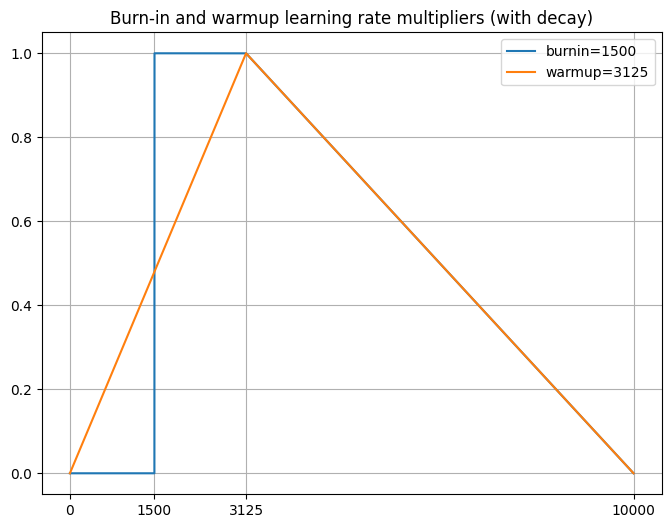

In [ ]:
x = np.arange(0, 10_000)

y_warmup = np.zeros_like(x, dtype=float)
y_warmup[0:3125] = np.linspace(0, 1, 3125, endpoint=False)
y_warmup[3125:] = np.linspace(1, 0, x.shape[0]-3125)

y_burnin = np.zeros_like(x, dtype=float)
y_burnin[1500:3125] = 1
y_burnin[3125:] = np.linspace(1, 0, x.shape[0]-3125)

plt.figure(figsize=(8, 6))

plt.plot(x, y_burnin, label="burnin=1500")
plt.plot(x, y_warmup, label="warmup=3125")

plt.xticks([0, 1500, 3125, 10_000])
plt.grid()
plt.legend()
plt.title("Burn-in and warmup learning rate multipliers (with decay)")

# Gridsearch

File not found: train_loss_Alg1_Warmup_3125_1e-5.txt


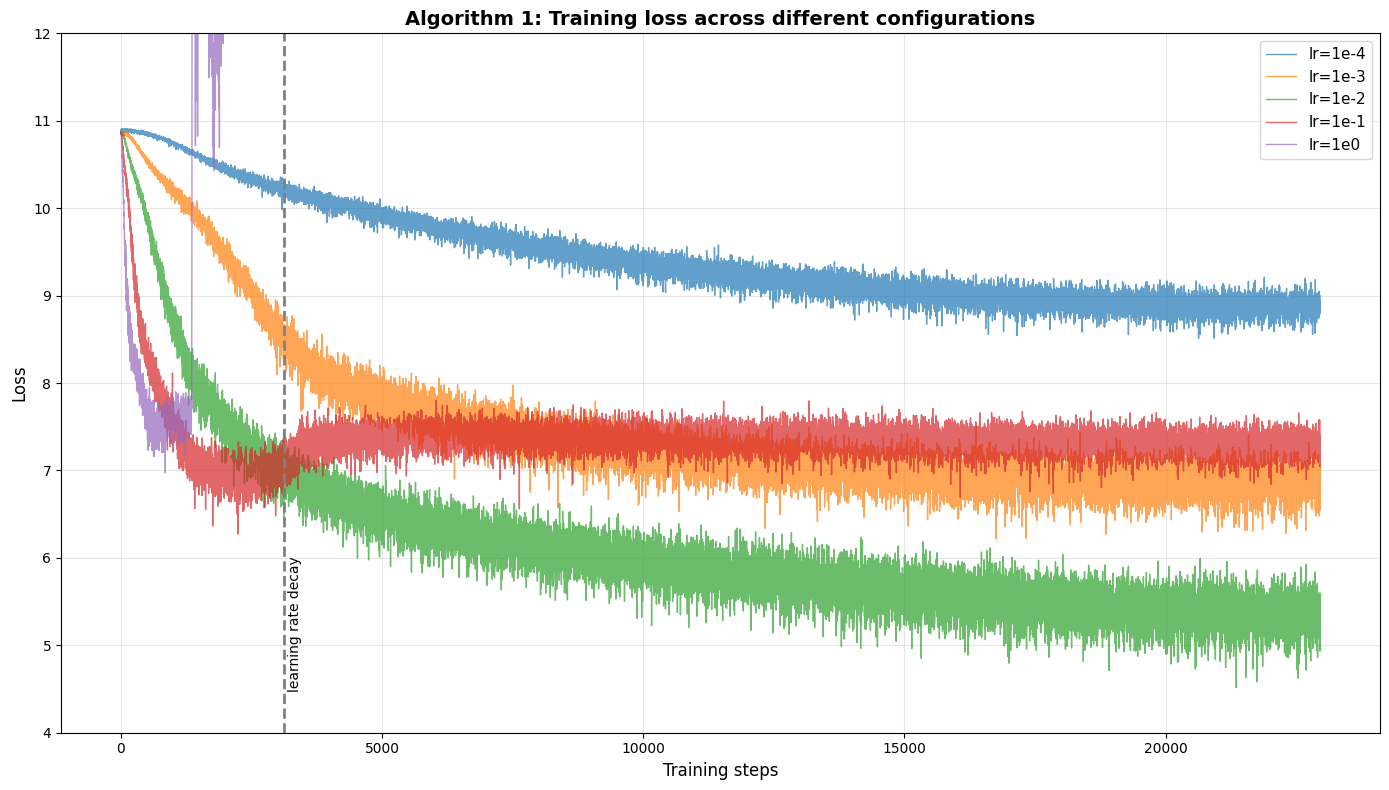

In [37]:
plt.figure(figsize=(14, 8))

for name, description in GRIDSEARCH_CONFIGS:
    try:
        train_loss_data = np.loadtxt(f"smallgpt-tails-results/gridsearch/train_loss_{ALG_NAME[0]}_Warmup_3125_{name}.txt")
        plt.plot(train_loss_data, label=description, linewidth=1, alpha=0.7)
    except FileNotFoundError:
        print(f"File not found: train_loss_{ALG_NAME[0]}_Warmup_3125_{name}.txt")

plt.vlines(x=3125, ymin=4, ymax=12, color='gray', linestyle='--', linewidth=2)
plt.annotate("learning rate decay", xy=(3200, 4.5), rotation=90, fontsize=10)

plt.ylim(4, 12)
plt.xlabel("Training steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title(f"{ALG_NAME[1]}: Training loss across different configurations", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

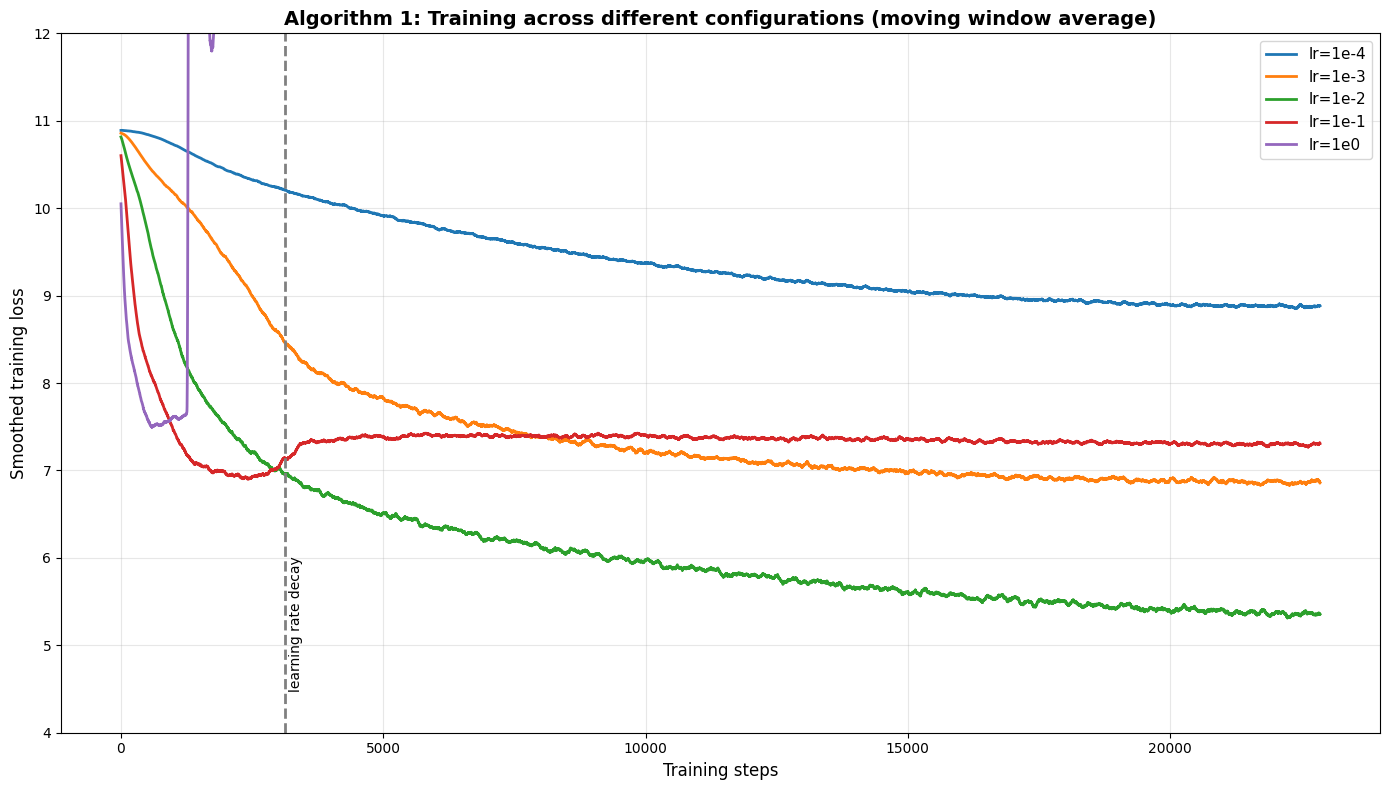

In [39]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

for name, description in GRIDSEARCH_CONFIGS:
    try:
        train_loss_data = np.loadtxt(f"smallgpt-tails-results/gridsearch/train_loss_{ALG_NAME[0]}_Warmup_3125_{name}.txt")
        
        smoothed_loss = smooth_curve(train_loss_data, window_size=100)
        steps_x = np.arange(len(smoothed_loss))
        
        plt.plot(steps_x, smoothed_loss, label=description, linewidth=2)
    except FileNotFoundError:
        pass
    
plt.vlines(x=3125, ymin=4, ymax=12, color='gray', linestyle='--', linewidth=2)
plt.annotate("learning rate decay", xy=(3200, 4.5), rotation=90, fontsize=10)

plt.ylim(4, 12)
plt.xlabel("Training steps", fontsize=12)
plt.ylabel("Smoothed training loss", fontsize=12)
plt.title(f"{ALG_NAME[1]}: Training across different configurations (moving window average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

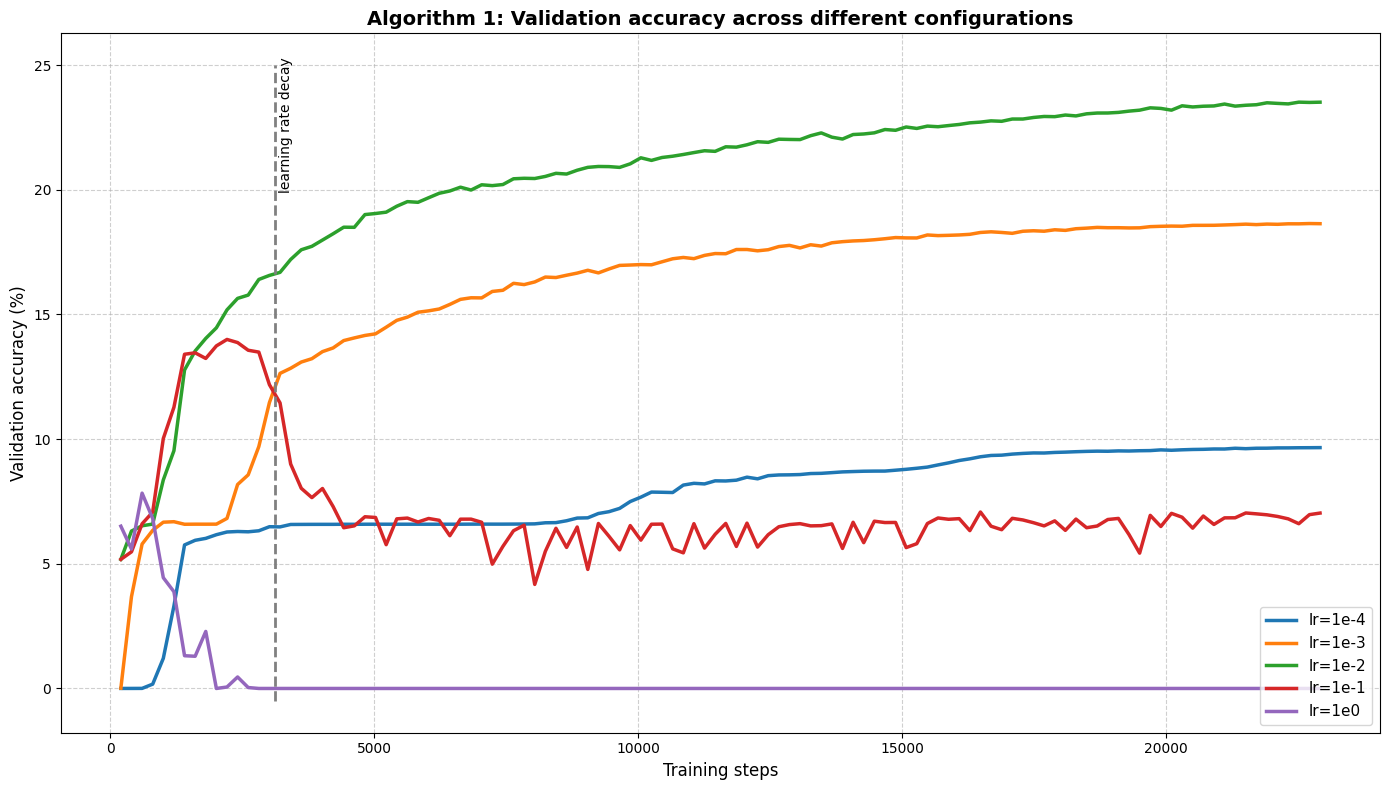

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 8))

for name, description in GRIDSEARCH_CONFIGS:
    try:
        val_acc_data = np.loadtxt(f"smallgpt-tails-results/gridsearch/val_acc_{ALG_NAME[0]}_Warmup_3125_{name}.txt")
        train_loss_data = np.loadtxt(f"smallgpt-tails-results/gridsearch/train_loss_{ALG_NAME[0]}_Warmup_3125_{name}.txt")
        
        epochs_count = len(val_acc_data)
        total_steps = len(train_loss_data)
        steps_per_epoch = total_steps // epochs_count
        
        steps_x = np.arange(1, epochs_count + 1) * steps_per_epoch
        
        plt.plot(steps_x, val_acc_data * 100, label=description, linewidth=2.5)
    except FileNotFoundError:
        pass

plt.vlines(x=3125, ymin=-0.5, ymax=25, color='gray', linestyle='--', linewidth=2)
plt.annotate("learning rate decay", xy=(3200, 20), rotation=90, fontsize=10)

plt.xlabel("Training steps", fontsize=12)
plt.ylabel("Validation accuracy (%)", fontsize=12)
plt.title(f"{ALG_NAME[1]}: Validation accuracy across different configurations", fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

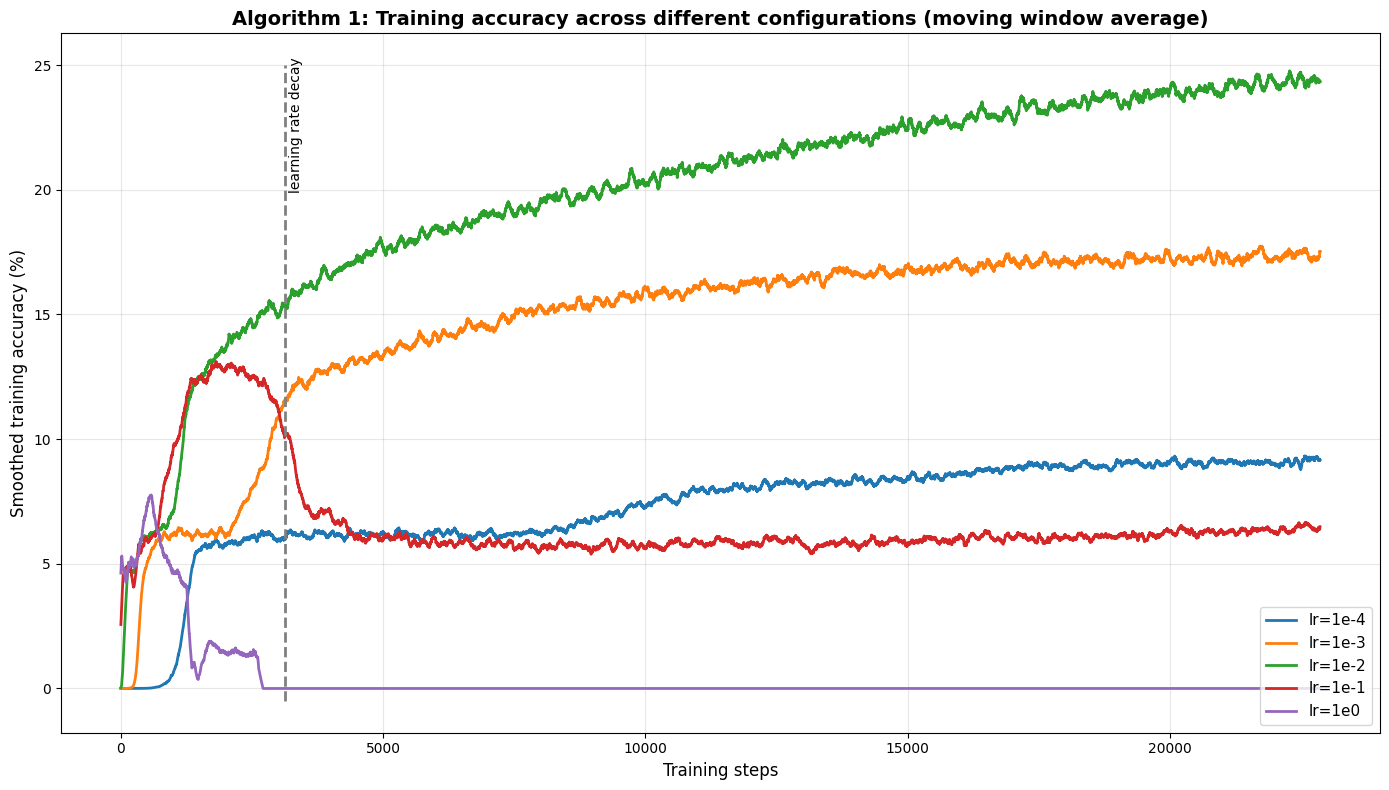

In [48]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

for name, description in GRIDSEARCH_CONFIGS:
    try:
        train_acc_data = np.loadtxt(f"smallgpt-tails-results/gridsearch/train_acc_{ALG_NAME[0]}_Warmup_3125_{name}.txt")
        
        smoothed_acc = smooth_curve(train_acc_data * 100, window_size=100)
        steps_x = np.arange(len(smoothed_acc))
        
        plt.plot(steps_x, smoothed_acc, label=description, linewidth=2)
    except FileNotFoundError:
        pass

plt.vlines(x=3125, ymin=-0.5, ymax=25, color='gray', linestyle='--', linewidth=2)
plt.annotate("learning rate decay", xy=(3200, 20), rotation=90, fontsize=10)

plt.xlabel("Training steps", fontsize=12)
plt.ylabel("Smoothed training accuracy (%)", fontsize=12)
plt.title(f"{ALG_NAME[1]}: Training accuracy across different configurations (moving window average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Burnin/Warmup comparison

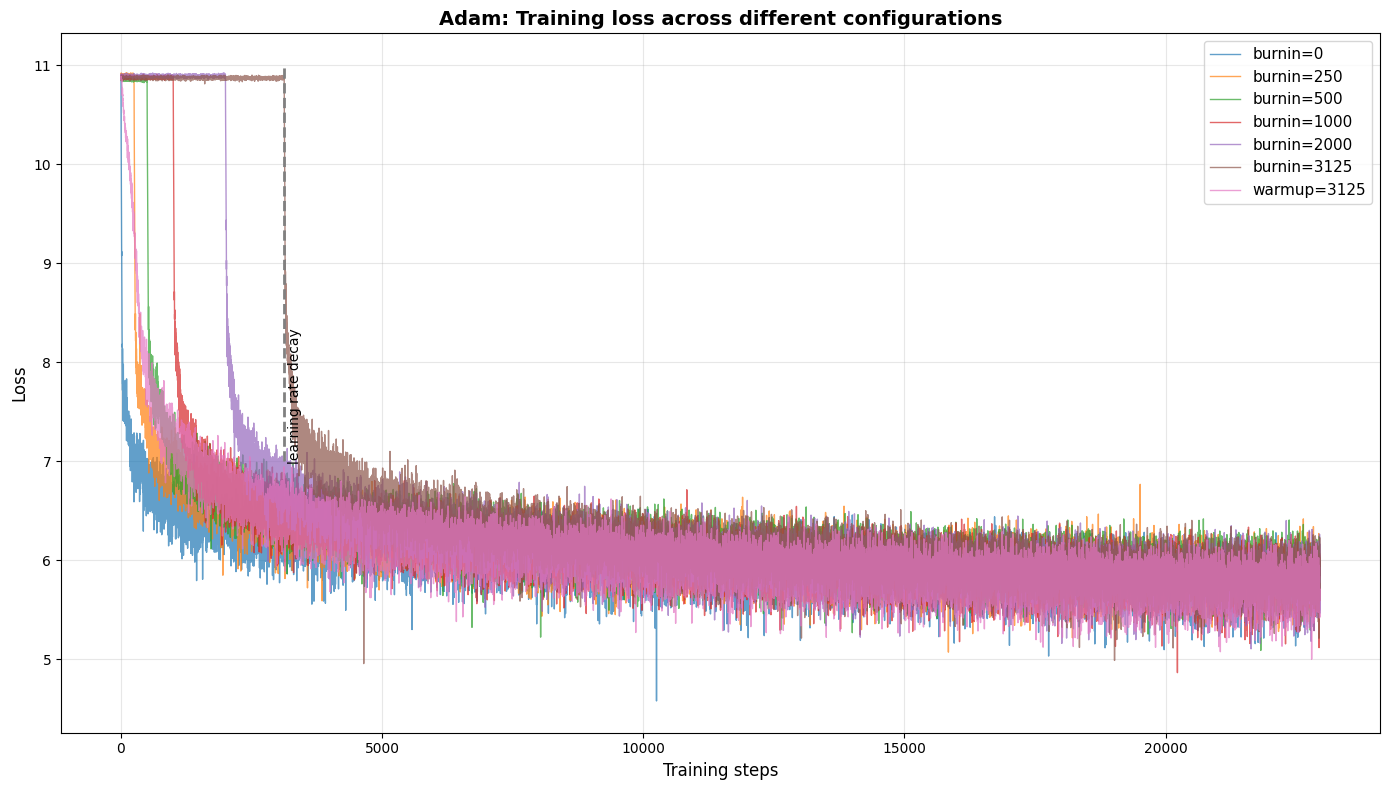

In [30]:
plt.figure(figsize=(14, 8))

for name, description in BURNIN_CONFIGS:
    try:
        train_loss_data = np.loadtxt(f"smallgpt-tails-results/good_lr/train_loss_{ALG_NAME[0]}_{name}.txt")
        plt.plot(train_loss_data, label=description, linewidth=1, alpha=0.7)
    except FileNotFoundError:
        print(f"File not found: train_loss_{ALG_NAME[0]}_{name}.txt")

plt.vlines(x=3125, ymin=7, ymax=11, color='gray', linestyle='--', linewidth=2)
plt.annotate("learning rate decay", xy=(3200, 7), rotation=90, fontsize=10)

plt.xlabel("Training steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title(f"{ALG_NAME[1]}: Training loss across different configurations", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

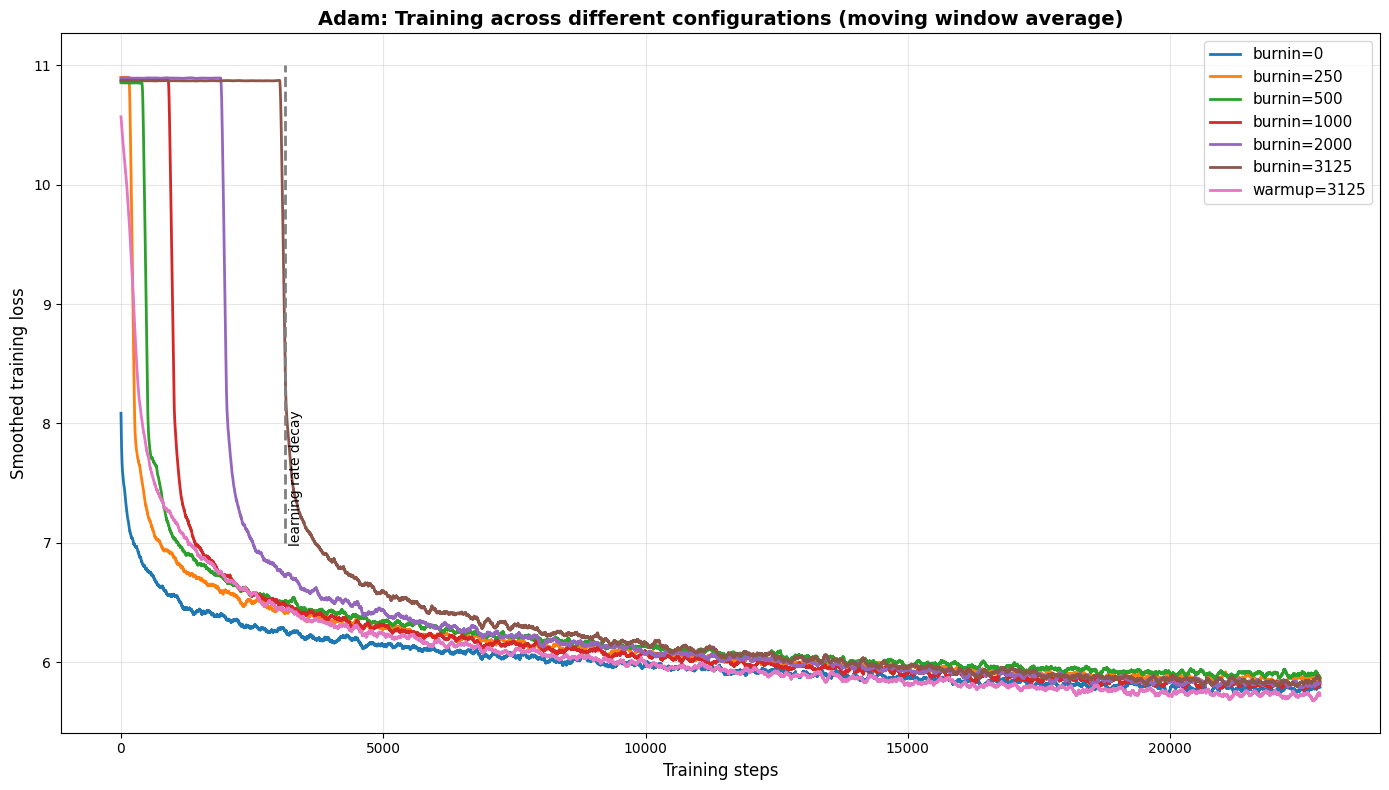

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

for name, description in BURNIN_CONFIGS:
    try:
        train_loss_data = np.loadtxt(f"smallgpt-tails-results/good_lr/train_loss_{ALG_NAME[0]}_{name}.txt")
        
        smoothed_loss = smooth_curve(train_loss_data, window_size=100)
        steps_x = np.arange(len(smoothed_loss))
        
        plt.plot(steps_x, smoothed_loss, label=description, linewidth=2)
    except FileNotFoundError:
        pass
    
plt.vlines(x=3125, ymin=7, ymax=11, color='gray', linestyle='--', linewidth=2)
plt.annotate("learning rate decay", xy=(3200, 7), rotation=90, fontsize=10)


plt.xlabel("Training steps", fontsize=12)
plt.ylabel("Smoothed training loss", fontsize=12)
plt.title(f"{ALG_NAME[1]}: Training across different configurations (moving window average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

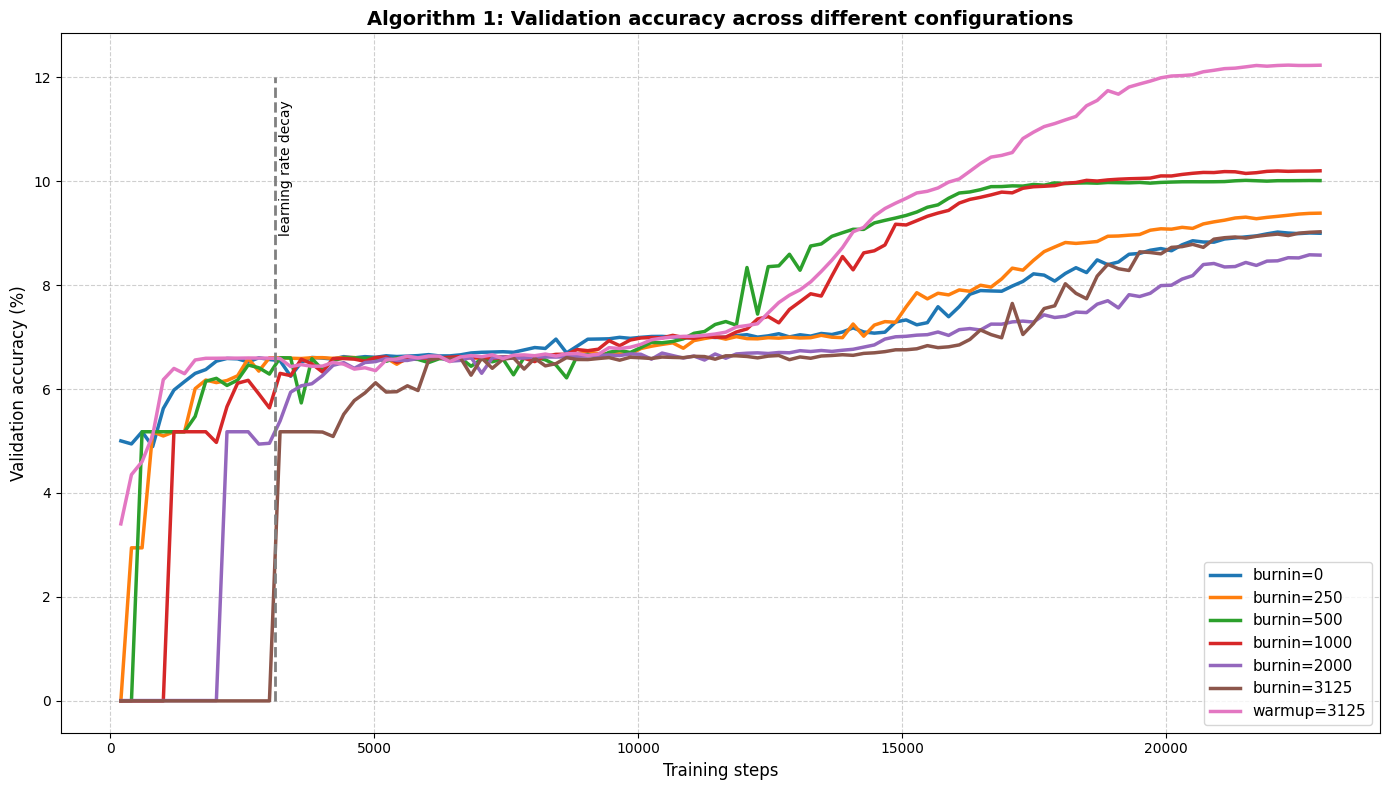

In [49]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 8))

for name, description in BURNIN_CONFIGS:
    try:
        val_acc_data = np.loadtxt(f"smallgpt-tails-results/good_lr/val_acc_{ALG_NAME[0]}_{name}.txt")
        train_loss_data = np.loadtxt(f"smallgpt-tails-results/good_lr/train_loss_{ALG_NAME[0]}_{name}.txt")
        
        epochs_count = len(val_acc_data)
        total_steps = len(train_loss_data)
        steps_per_epoch = total_steps // epochs_count
        
        steps_x = np.arange(1, epochs_count + 1) * steps_per_epoch
        
        plt.plot(steps_x, val_acc_data * 100, label=description, linewidth=2.5)
    except FileNotFoundError:
        pass

plt.vlines(x=3125, ymin=0, ymax=12, color='gray', linestyle='--', linewidth=2)
plt.annotate("learning rate decay", xy=(3200, 9), rotation=90, fontsize=10)

plt.xlabel("Training steps", fontsize=12)
plt.ylabel("Validation accuracy (%)", fontsize=12)
plt.title(f"{ALG_NAME[1]}: Validation accuracy across different configurations", fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

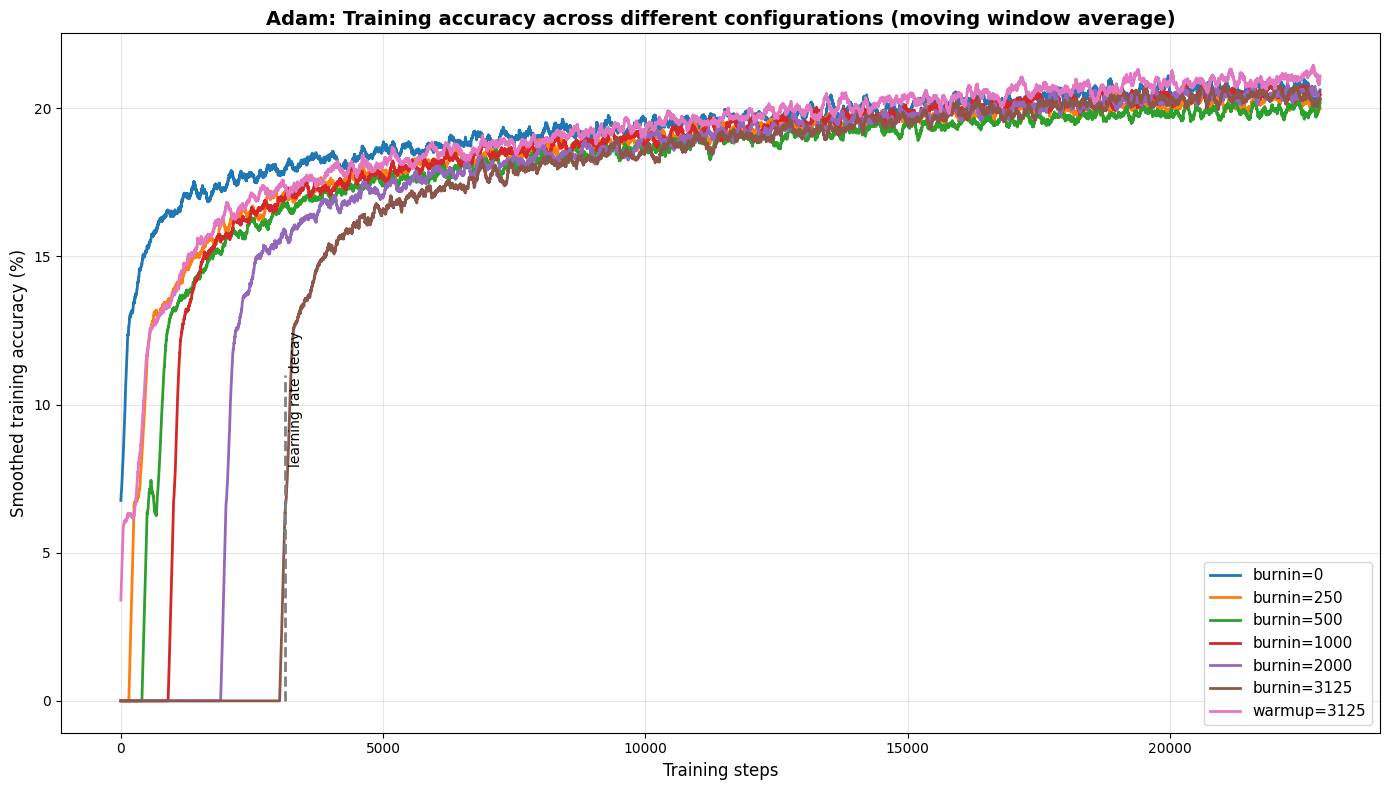

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

for name, description in BURNIN_CONFIGS:
    try:
        train_acc_data = np.loadtxt(f"smallgpt-tails-results/good_lr/train_acc_{ALG_NAME[0]}_{name}.txt")
        
        smoothed_acc = smooth_curve(train_acc_data * 100, window_size=100)
        steps_x = np.arange(len(smoothed_acc))
        
        plt.plot(steps_x, smoothed_acc, label=description, linewidth=2)
    except FileNotFoundError:
        pass

plt.vlines(x=3125, ymin=0, ymax=11, color='gray', linestyle='--', linewidth=2)
plt.annotate("learning rate decay", xy=(3200, 8), rotation=90, fontsize=10)

plt.xlabel("Training steps", fontsize=12)
plt.ylabel("Smoothed training accuracy (%)", fontsize=12)
plt.title(f"{ALG_NAME[1]}: Training accuracy across different configurations (moving window average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()